In [1]:
import os
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch import nn, optim
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Load the pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Freeze all layers in the network
for param in model.parameters():
    param.requires_grad = False

/home/dream/.virtualenvs/LLM/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dream/.virtualenvs/LLM/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
# Replace the final fully connected layer
model.fc = nn.Linear(512, 2)

In [4]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Define transformations for the images
transform = transforms.Compose(
        [
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
)

In [5]:
# Set up the device for GPU training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move the model to the device
model.to(device)

# Number of epochs
num_epochs = 10  # Adjust as needed

In [6]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder(root="chest_xray/train", transform=transform)
test_dataset = ImageFolder(root="chest_xray/test", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
for epoch in range(num_epochs):
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Brain tumor image classification

In [8]:
from torchvision import transforms

# Modify the data transformation for grayscale images
transforms = transforms.Compose(
        [
            transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(), transforms.RandomRotation(10),
            transforms.Grayscale(num_output_channels=3), transforms.ToTensor(),
            transforms.Normalize(mean=[0.485], std=[0.229])  # Use single value for mean and std
        ]
)
train_dataset = ImageFolder('brain-tumor-mri-dataset/Training', transform=transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = ImageFolder('brain-tumor-mri-dataset/Testing', transform=transforms)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [9]:
from efficientnet_pytorch import EfficientNet

num_classes = 4
model = EfficientNet.from_pretrained('efficientnet-b0')  # Using EfficientNet-B0
num_ftrs = model._fc.in_features
model._fc = nn.Linear(num_ftrs, num_classes)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

Loaded pretrained weights for efficientnet-b0


EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False
    

In [10]:
for epoch in range(num_epochs):
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Visualizing feature maps in a pre-trained Faster R-CNN model

/home/dream/.virtualenvs/LLM/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


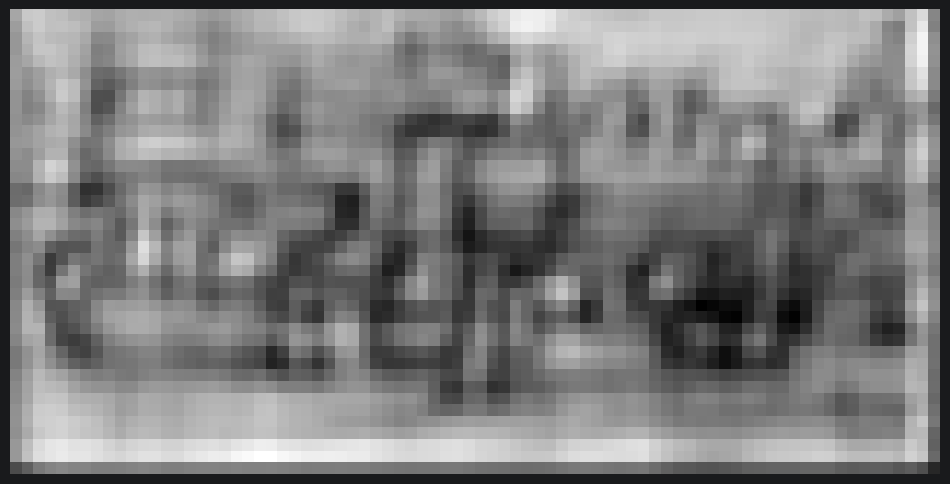

In [11]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F

# Load the pre-trained model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load and preprocess an image
image_path = "image1-1.png"
image = Image.open(image_path)
image_tensor = F.to_tensor(image).unsqueeze(0)

# Forward pass through the backbone
with torch.no_grad():
    features = model.backbone(image_tensor)

# Visualize one of the feature maps
feature_map = features['0'].squeeze(0)  # Selecting the first feature map
plt.figure(figsize=(12, 12))
plt.imshow(feature_map[0].cpu().numpy(), cmap='gray')  # Visualize the first channel
plt.axis('off')
plt.show()

In [12]:
import numpy as np


# Visualize selected feature maps
def visualize_selected_feature_maps(image_data, num_maps=5):
    feature_maps = feature_model.predict(image_data)
    feature_maps = np.squeeze(feature_maps, axis=0) # Remove batch dimension
    plt.figure(figsize=(20, 4))
    plt.suptitle("Selected Feature Maps", fontsize=16)

    for i in range(num_maps):
        plt.subplot(1, num_maps, i + 1)
        plt.imshow(feature_maps[:, :, i], cmap='viridis')
        plt.axis('off')

    plt.show()

# Faster R-CNN

In [13]:
# Label Mapping from VOC
LABEL_MAP = {
    'background': 0,  # Often, a background class is added
    'aeroplane': 1, 'bicycle': 2, 'bird': 3, 'boat': 4, 'bottle': 5, 'bus': 6, 'car': 7, 'cat': 8, 'chair': 9,
    'cow': 10, 'diningtable': 11, 'dog': 12, 'horse': 13, 'motorbike': 14, 'person': 15, 'pottedplant': 16, 'sheep': 17,
    'sofa': 18, 'train': 19, 'tvmonitor': 20
}

In [14]:
from torchvision.datasets import VOCDetection


# Custom Dataset Class
class CustomVOCDataset(VOCDetection):
    def __init__(self, root, image_set, download, transform=None):
        super(CustomVOCDataset, self).__init__(root, year='2012', image_set=image_set, download=download)
        self.transform = transform

    def __getitem__(self, idx):
        img, target = super(CustomVOCDataset, self).__getitem__(idx)

        if self.transform:
            img = self.transform(img)

        # Convert labels from strings to integers
        annotations = target['annotation']['object']
        boxes = []
        labels = []
        if not isinstance(annotations, list):
            annotations = [annotations]
        for obj in annotations:
            bbox = obj['bndbox']
            boxes.append(
                    [
                        int(bbox['xmin']), int(bbox['ymin']),
                        int(bbox['xmax']), int(bbox['ymax'])
                    ]
            )
            labels.append(LABEL_MAP[obj['name']])  # Convert string labels to integers
        target = {}
        target['boxes'] = torch.as_tensor(boxes, dtype=torch.float32)
        target['labels'] = torch.as_tensor(labels, dtype=torch.int64)
        return img, target

In [15]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [16]:
import torchvision.transforms as transforms


def get_transform():
    return transforms.Compose([transforms.ToTensor()])

In [17]:
from torch.utils.data import Subset

# Load Dataset
train_dataset = CustomVOCDataset(root='./data/VOC2012', image_set='train', download=True, transform=get_transform())
train_dataset = Subset(train_dataset, range(1000))  # Subset for demonstration
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

In [18]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


def create_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = create_model(num_classes=21)  # Including background class
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
losses = []